In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [35]:
# ── Constants ─────────────────────────────────────────────────────────────────
DATA_ROOT_PATH    = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_v2"
POWER_MODES       = ["HPM", "RPM", "LPM"]
FS_STR_LIST       = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]
FS_LIST           = [500e3, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6]
FI_LIST           = [99.915e3, 99.976e3, 99.854e3, 99.976e3, 100.098e3, 99.487e3, 98.877e3]
J_LIST            = [1637, 819, 409, 273, 205, 163, 135]
BUFFER_SIZE       = 8192
REF_HI            = 2.8
REF_LO            = 0.8
SHUNT_RESISTANCE  = 1.02

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.59e-3, "1M": 4.93e-3, "2M": 5.58e-3, "3M": 6.14e-3, "4M": 6.71e-3, "5M": 7.29e-3, "6M": 7.83e-3},
    "RPM": {"500k": 3.23e-3, "1M": 3.57e-3, "2M": 4.18e-3, "3M": 4.79e-3, "4M": 5.37e-3, "5M": 5.91e-3, "6M": 6.15e-3},
    "LPM": {"500k": 2.49e-3, "1M": 2.87e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 5.83e-3},
}

POWER_W = {
    pm: {fs: (v**2 / SHUNT_RESISTANCE) for fs, v in fs_dict.items()}
    for pm, fs_dict in SHUNT_VOLTAGE.items()
}

hann_window = np.hanning(BUFFER_SIZE)

In [36]:
# ── Load raw data ─────────────────────────────────────────────────────────────
raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for power_mode_folder in os.listdir(DATA_ROOT_PATH):
    power_mode_folder_path = os.path.join(DATA_ROOT_PATH, power_mode_folder)
    if os.path.isdir(power_mode_folder_path) and power_mode_folder in POWER_MODES:
        for Fs_folder in os.listdir(power_mode_folder_path):
            Fs_path = os.path.join(power_mode_folder_path, Fs_folder)
            if os.path.isdir(Fs_path):
                for csv_file in glob.glob(os.path.join(Fs_path, "*.csv")):
                    df = pd.read_csv(csv_file)
                    for k, col in enumerate(df.columns):
                        raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


/tmp/ipykernel_1137349/2979450427.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


In [37]:
# ── Helper functions ──────────────────────────────────────────────────────────
def alias(harmonic_freq, fs, N):
    a = harmonic_freq % fs
    if a > fs / 2:
        a = fs - a
    return int(round(a / fs * N))

def tabei_ueda(fft_full, fft_mag, N, hann_window):
    """Returns (A, fx, Po) — amplitude (V), fractional bin, phase (rad)."""
    fft_pos = fft_mag[:N//2]
    kmax    = np.argmax(fft_pos[1:]) + 1

    if fft_mag[kmax - 1] > fft_mag[kmax + 1]:
        r  = fft_mag[kmax - 1] / fft_mag[kmax]
        fx = kmax + (1.0 - 2.0*r) / (1.0 + r)
    else:
        r  = fft_mag[kmax + 1] / fft_mag[kmax]
        fx = kmax - (1.0 - 2.0*r) / (1.0 + r)

    dx   = fx - kmax
    dy   = np.pi * dx
    sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0
    CG   = np.sum(hann_window) / N

    A  = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0) / CG * 2.0
    Po = (1 / (2*np.pi)) * np.angle(fft_full[kmax] * np.exp(-1j * dy))
    return A, fx, Po


In [38]:
HIGHLIGHT_FS = "1M"
HIGHLIGHT_PM = "HPM"

RAW_ADC_SIGNAL = []
AC_COUPLED_SIGNAL = []
FFT_OF_UNWINDOWED_SIGNAL = []
HANNING_WINDOW_SIGNAL = []
FFT_OF_HANNING_WINDOW_IN_DB = []
FFT_OF_IDEAL_SIGNAL = []
FFT_OF_NAD = []
FFT_OF_NOISE_ONLY = []

results = []

for pm in POWER_MODES:
    for fs_str, fs, J in zip(FS_STR_LIST, FS_LIST, J_LIST):

        test_cols = [c for c in raw_dfs[pm].columns if c.startswith(fs_str)]

        signal_pow_list = []
        noise_pow_list  = []
        harm_pow_list   = []
        noise_fft_mag   = None   # keep last valid one for SFDR

        for col in test_cols:
            waveform_code = np.array(raw_dfs[pm][col].to_list())
            signal = (waveform_code / 255) * 2.0 - 1.0
            signal = signal - np.mean(signal)
            N = len(signal)

            # ── Skip flat/bad captures ────────────────────────────────────────
            if np.std(signal) < 0.01:
                print(f"  Skip {pm}/{fs_str}/{col} — flat signal")
                continue

            windowed = signal * hann_window
            fft_full = np.fft.fft(windowed)
            fft_mag  = np.abs(fft_full)

            # ── T&U interpolation ─────────────────────────────────────────────
            A, fx, Po = tabei_ueda(fft_full, fft_mag, N, hann_window)
            f_est     = fx * (fs / N)

            if not np.isfinite(A) or not np.isfinite(f_est) or A <= 0:
                print(f"  Skip {pm}/{fs_str}/{col} — T&U failed (A={A:.4f}, f={f_est:.1f})")
                continue

            # ── Ideal sine reconstruction and noise ───────────────────────────
            t     = np.arange(N) / fs
            ideal = A * np.cos(2 * np.pi * f_est * t + 2 * np.pi * Po)
            noise = signal - ideal

            signal_pow_list.append(np.mean(ideal**2))
            noise_pow_list.append(np.mean(noise**2))

            # ── Harmonic power from noise residual FFT ────────────────────────
            CG            = np.sum(hann_window) / N
            noise_fft_mag = np.abs(np.fft.fft(noise * hann_window)) / N / CG * 2
            harm_pows     = []
            for k in range(2, 11):
                idx = alias(k * f_est, fs, N)
                if 0 < idx < N//2:
                    harm_pows.append(noise_fft_mag[idx]**2 / 2)
            harm_pow_list.append(np.sum(harm_pows))

        # ── Skip if no valid captures ─────────────────────────────────────────
        if len(signal_pow_list) == 0:
            print(f"  WARNING: no valid captures for {pm}/{fs_str} — skipping row")
            continue

        # ── Average across captures ───────────────────────────────────────────
        avg_signal_pow = np.mean(signal_pow_list)
        avg_noise_pow  = np.mean(noise_pow_list)
        avg_harm_pow   = np.mean(harm_pow_list)

        rms_signal = np.sqrt(avg_signal_pow)
        rms_noise  = np.sqrt(avg_noise_pow)
        rms_harm   = np.sqrt(avg_harm_pow)

        # ── Metrics ───────────────────────────────────────────────────────────
        SINAD = 20 * np.log10(rms_signal / rms_noise)
        ENOB  = (SINAD - 1.76) / 6.02

        rms_noise_only = np.sqrt(max(avg_noise_pow - avg_harm_pow, 1e-30))
        SNR  = 20 * np.log10(rms_signal / rms_noise_only)
        THD  = 20 * np.log10(rms_harm / rms_signal) if rms_harm > 0 else -np.inf

        # ── SFDR: loudest spur in noise residual (last valid capture) ─────────
        sfdr_mag = noise_fft_mag.copy()
        sfdr_mag[:3] = 0
        SFDR = -20 * np.log10(np.max(sfdr_mag[:N//2]) / (rms_signal * np.sqrt(2)))

        # ── DR: noise floor vs full scale ─────────────────────────────────────
        DR = -20 * np.log10(rms_noise / 1.0)

        power = POWER_W[pm][fs_str]
        FOMw  = power / (2**ENOB * fs)

        results.append({
            "Power Mode":    pm,
            "Fs":            fs_str,
            "ENOB (bits)":   round(ENOB, 2),
            "SNR (dB)":      round(SNR, 2),
            "SINAD (dB)":    round(SINAD, 2),
            "THD (dBFS)":    round(THD, 2),
            "SFDR (dBFS)":   round(SFDR, 2),
            "DR (dBFS)":     round(DR, 2),
            "Power (W)":     power,
            "FOMw (J/step)": FOMw,
        })

        print(f"  {pm}/{fs_str}: ENOB={ENOB:.2f} bits, SINAD={SINAD:.2f} dB, "
              f"SNR={SNR:.2f} dB, THD={THD:.2f} dBFS, captures={len(signal_pow_list)}")

# ── Results table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results, columns=[
    "Power Mode", "Fs", "ENOB (bits)", "SNR (dB)", "SINAD (dB)",
    "THD (dBFS)", "SFDR (dBFS)", "DR (dBFS)", "Power (W)", "FOMw (J/step)"
])

results_df

  HPM/500k: ENOB=4.40 bits, SINAD=28.27 dB, SNR=33.53 dB, THD=-29.80 dBFS, captures=100
  HPM/1M: ENOB=4.50 bits, SINAD=28.88 dB, SNR=33.84 dB, THD=-30.55 dBFS, captures=100
  HPM/2M: ENOB=4.51 bits, SINAD=28.90 dB, SNR=33.20 dB, THD=-30.91 dBFS, captures=100
  HPM/3M: ENOB=4.09 bits, SINAD=26.38 dB, SNR=30.66 dB, THD=-28.40 dBFS, captures=100
  HPM/4M: ENOB=3.89 bits, SINAD=25.18 dB, SNR=28.88 dB, THD=-27.59 dBFS, captures=100
  HPM/5M: ENOB=0.88 bits, SINAD=7.06 dB, SNR=10.22 dB, THD=-9.92 dBFS, captures=100
  HPM/6M: ENOB=-0.13 bits, SINAD=0.97 dB, SNR=2.01 dB, THD=-7.68 dBFS, captures=100
  RPM/500k: ENOB=4.53 bits, SINAD=29.01 dB, SNR=34.01 dB, THD=-30.66 dBFS, captures=100
  RPM/1M: ENOB=4.62 bits, SINAD=29.59 dB, SNR=33.96 dB, THD=-31.56 dBFS, captures=100
  RPM/2M: ENOB=4.06 bits, SINAD=26.21 dB, SNR=29.37 dB, THD=-29.09 dBFS, captures=100
  RPM/3M: ENOB=3.88 bits, SINAD=25.14 dB, SNR=27.68 dB, THD=-28.67 dBFS, captures=100
  RPM/4M: ENOB=3.66 bits, SINAD=23.78 dB, SNR=27.10 dB

,Power Mode,Fs,ENOB (bits),SNR (dB),SINAD (dB),THD (dBFS),SFDR (dBFS),DR (dBFS),Power (W),FOMw (J/step)
0,HPM,500k,4.40,33.53,28.27,-29.80,30.90,31.56,0.000021,1.952423e-12
1,HPM,1M,4.50,33.84,28.88,-30.55,31.94,32.16,0.000024,1.049701e-12
2,HPM,2M,4.51,33.20,28.90,-30.91,32.73,32.19,0.000031,6.708294e-13
3,HPM,3M,4.09,30.66,26.38,-28.40,28.93,29.49,0.000037,7.239917e-13
4,HPM,4M,3.89,28.88,25.18,-27.59,28.07,28.25,0.000044,7.443162e-13
5,HPM,5M,0.88,10.22,7.06,-9.92,9.90,9.79,0.000052,5.662055e-12
6,HPM,6M,-0.13,2.01,0.97,-7.68,12.51,6.72,0.000060,1.097264e-11
7,RPM,500k,4.53,34.01,29.01,-30.66,31.34,32.22,0.000010,8.878274e-13
8,RPM,1M,4.62,33.96,29.59,-31.56,32.57,32.80,0.000012,5.073049e-13
9,RPM,2M,4.06,29.37,26.21,-29.09,29.78,29.31,0.000017,5.127578e-13


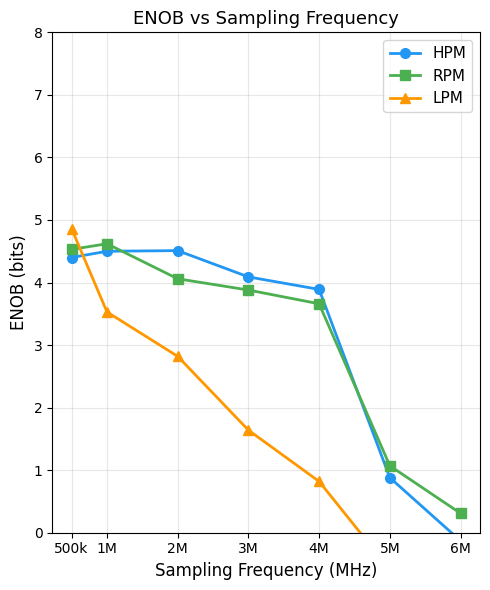

In [39]:
fig, ax = plt.subplots(figsize=(5, 6))

colors = {"HPM": "#2196F3", "RPM": "#4CAF50", "LPM": "#FF9800"}
markers = {"HPM": "o", "RPM": "s", "LPM": "^"}

for pm in POWER_MODES:
    pm_df = results_df[results_df["Power Mode"] == pm]
    fs_vals   = [FS_LIST[FS_STR_LIST.index(fs)] / 1e6 for fs in pm_df["Fs"]]
    enob_vals = pm_df["ENOB (bits)"].values

    ax.plot(fs_vals, enob_vals,
            color=colors[pm], marker=markers[pm],
            linewidth=2, markersize=7, label=pm)

ax.set_xlabel("Sampling Frequency (MHz)", fontsize=12)
ax.set_ylabel("ENOB (bits)", fontsize=12)
ax.set_title("ENOB vs Sampling Frequency", fontsize=13)
ax.set_ylim(0, 8)
ax.set_xticks([f / 1e6 for f in FS_LIST])
ax.set_xticklabels(FS_STR_LIST)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
for pm in POWER_MODES:
    for fs_str, fs, J in zip(FS_STR_LIST, FS_LIST, J_LIST):

        test_cols = [c for c in raw_dfs[pm].columns if c.startswith(fs_str)]

        signal_pow_list = []
        noise_pow_list  = []
        harm_pow_list   = []
        noise_fft_mag   = None

        for col in test_cols:
            waveform_code = np.array(raw_dfs[pm][col].to_list())
            signal = (waveform_code / 255) * 2.0 - 1.0
            signal = signal - np.mean(signal)
            N = len(signal)

            if np.std(signal) < 0.01:
                print(f"  Skip {pm}/{fs_str}/{col} — flat signal")
                continue

            windowed = signal * hann_window
            fft_full = np.fft.fft(windowed)
            fft_mag  = np.abs(fft_full)

            A, fx, Po = tabei_ueda(fft_full, fft_mag, N, hann_window)
            f_est     = fx * (fs / N)

            if not np.isfinite(A) or not np.isfinite(f_est) or A <= 0:
                print(f"  Skip {pm}/{fs_str}/{col} — T&U failed (A={A:.4f}, f={f_est:.1f})")
                continue

            t     = np.arange(N) / fs
            ideal = A * np.cos(2 * np.pi * f_est * t + 2 * np.pi * Po)
            noise = signal - ideal

            signal_pow_list.append(np.mean(ideal**2))
            noise_pow_list.append(np.mean(noise**2))

            CG            = np.sum(hann_window) / N
            noise_fft_mag = np.abs(np.fft.fft(noise * hann_window)) / N / CG * 2
            harm_pows     = []
            for k in range(2, 11):
                idx = alias(k * f_est, fs, N)
                if 0 < idx < N//2:
                    harm_pows.append(noise_fft_mag[idx]**2 / 2)
            harm_pow_list.append(np.sum(harm_pows))

            # ── Capture plot data for highlighted pm/fs (first valid capture) ──
            if pm == HIGHLIGHT_PM and fs_str == HIGHLIGHT_FS and len(RAW_ADC_SIGNAL) == 0:
                f_axis = np.fft.fftfreq(N, d=1.0/fs)[:N//2]
                CG_plot = np.sum(hann_window) / N

                fft_unwindowed = np.abs(np.fft.fft(signal)) 
                fft_unwindowed_db = 20 * np.log10(fft_unwindowed[:N//2] / np.max(fft_unwindowed[:N//2]) + 1e-12)
                FFT_OF_UNWINDOWED_SIGNAL.extend(fft_unwindowed_db)

                RAW_ADC_SIGNAL.extend(waveform_code)
                AC_COUPLED_SIGNAL.extend(signal)
                HANNING_WINDOW_SIGNAL.extend(windowed)

                # FFT of windowed signal in dBFS
                fft_db = 20 * np.log10(fft_mag[:N//2] / np.max(fft_mag[:N//2]) + 1e-12)
                FFT_OF_HANNING_WINDOW_IN_DB.extend(fft_db)

                # FFT of ideal sine
                ideal_fft_mag = np.abs(np.fft.fft(ideal * hann_window)) / N / CG_plot * 2
                ideal_fft_db  = 20 * np.log10(ideal_fft_mag[:N//2] / (A / np.sqrt(2)) + 1e-12)
                FFT_OF_IDEAL_SIGNAL.extend(ideal_fft_db)

                # FFT of noise+distortion (NAD)
                nad_fft_mag = np.abs(np.fft.fft(noise * hann_window)) / N / CG_plot * 2
                nad_fft_db  = 20 * np.log10(nad_fft_mag[:N//2] / (A / np.sqrt(2)) + 1e-12)
                FFT_OF_NAD.extend(nad_fft_db)

                # FFT of noise only (zero out harmonic bins from NAD)
                noise_only_fft = nad_fft_mag.copy()
                for k in range(2, 11):
                    idx = alias(k * f_est, fs, N)
                    if 0 < idx < N//2:
                        noise_only_fft[max(0, idx-1):idx+2] = 0  # blank ±1 bin around each harmonic
                noise_only_db = 20 * np.log10(noise_only_fft[:N//2] / (A / np.sqrt(2)) + 1e-12)
                FFT_OF_NOISE_ONLY.extend(noise_only_db)

        if len(signal_pow_list) == 0:
            print(f"  WARNING: no valid captures for {pm}/{fs_str} — skipping row")
            continue

        avg_signal_pow = np.mean(signal_pow_list)
        avg_noise_pow  = np.mean(noise_pow_list)
        avg_harm_pow   = np.mean(harm_pow_list)

        rms_signal = np.sqrt(avg_signal_pow)
        rms_noise  = np.sqrt(avg_noise_pow)
        rms_harm   = np.sqrt(avg_harm_pow)

        SINAD = 20 * np.log10(rms_signal / rms_noise)
        ENOB  = (SINAD - 1.76) / 6.02

        rms_noise_only = np.sqrt(max(avg_noise_pow - avg_harm_pow, 1e-30))
        SNR  = 20 * np.log10(rms_signal / rms_noise_only)
        THD  = 20 * np.log10(rms_harm / rms_signal) if rms_harm > 0 else -np.inf

        sfdr_mag = noise_fft_mag.copy()
        sfdr_mag[:3] = 0
        SFDR = -20 * np.log10(np.max(sfdr_mag[:N//2]) / (rms_signal * np.sqrt(2)))

        DR   = -20 * np.log10(rms_noise / 1.0)
        power = POWER_W[pm][fs_str]
        FOMw  = power / (2**ENOB * fs)

        results.append({
            "Power Mode":    pm,
            "Fs":            fs_str,
            "ENOB (bits)":   round(ENOB, 2),
            "SNR (dB)":      round(SNR, 2),
            "SINAD (dB)":    round(SINAD, 2),
            "THD (dBFS)":    round(THD, 2),
            "SFDR (dBFS)":   round(SFDR, 2),
            "DR (dBFS)":     round(DR, 2),
            "Power (W)":     power,
            "FOMw (J/step)": FOMw,
        })

        print(f"  {pm}/{fs_str}: ENOB={ENOB:.2f} bits, SINAD={SINAD:.2f} dB, "
              f"SNR={SNR:.2f} dB, THD={THD:.2f} dBFS, captures={len(signal_pow_list)}")

  HPM/500k: ENOB=4.40 bits, SINAD=28.27 dB, SNR=33.53 dB, THD=-29.80 dBFS, captures=100
  HPM/1M: ENOB=4.50 bits, SINAD=28.88 dB, SNR=33.84 dB, THD=-30.55 dBFS, captures=100
  HPM/2M: ENOB=4.51 bits, SINAD=28.90 dB, SNR=33.20 dB, THD=-30.91 dBFS, captures=100
  HPM/3M: ENOB=4.09 bits, SINAD=26.38 dB, SNR=30.66 dB, THD=-28.40 dBFS, captures=100
  HPM/4M: ENOB=3.89 bits, SINAD=25.18 dB, SNR=28.88 dB, THD=-27.59 dBFS, captures=100
  HPM/5M: ENOB=0.88 bits, SINAD=7.06 dB, SNR=10.22 dB, THD=-9.92 dBFS, captures=100
  HPM/6M: ENOB=-0.13 bits, SINAD=0.97 dB, SNR=2.01 dB, THD=-7.68 dBFS, captures=100
  RPM/500k: ENOB=4.53 bits, SINAD=29.01 dB, SNR=34.01 dB, THD=-30.66 dBFS, captures=100
  RPM/1M: ENOB=4.62 bits, SINAD=29.59 dB, SNR=33.96 dB, THD=-31.56 dBFS, captures=100
  RPM/2M: ENOB=4.06 bits, SINAD=26.21 dB, SNR=29.37 dB, THD=-29.09 dBFS, captures=100
  RPM/3M: ENOB=3.88 bits, SINAD=25.14 dB, SNR=27.68 dB, THD=-28.67 dBFS, captures=100
  RPM/4M: ENOB=3.66 bits, SINAD=23.78 dB, SNR=27.10 dB

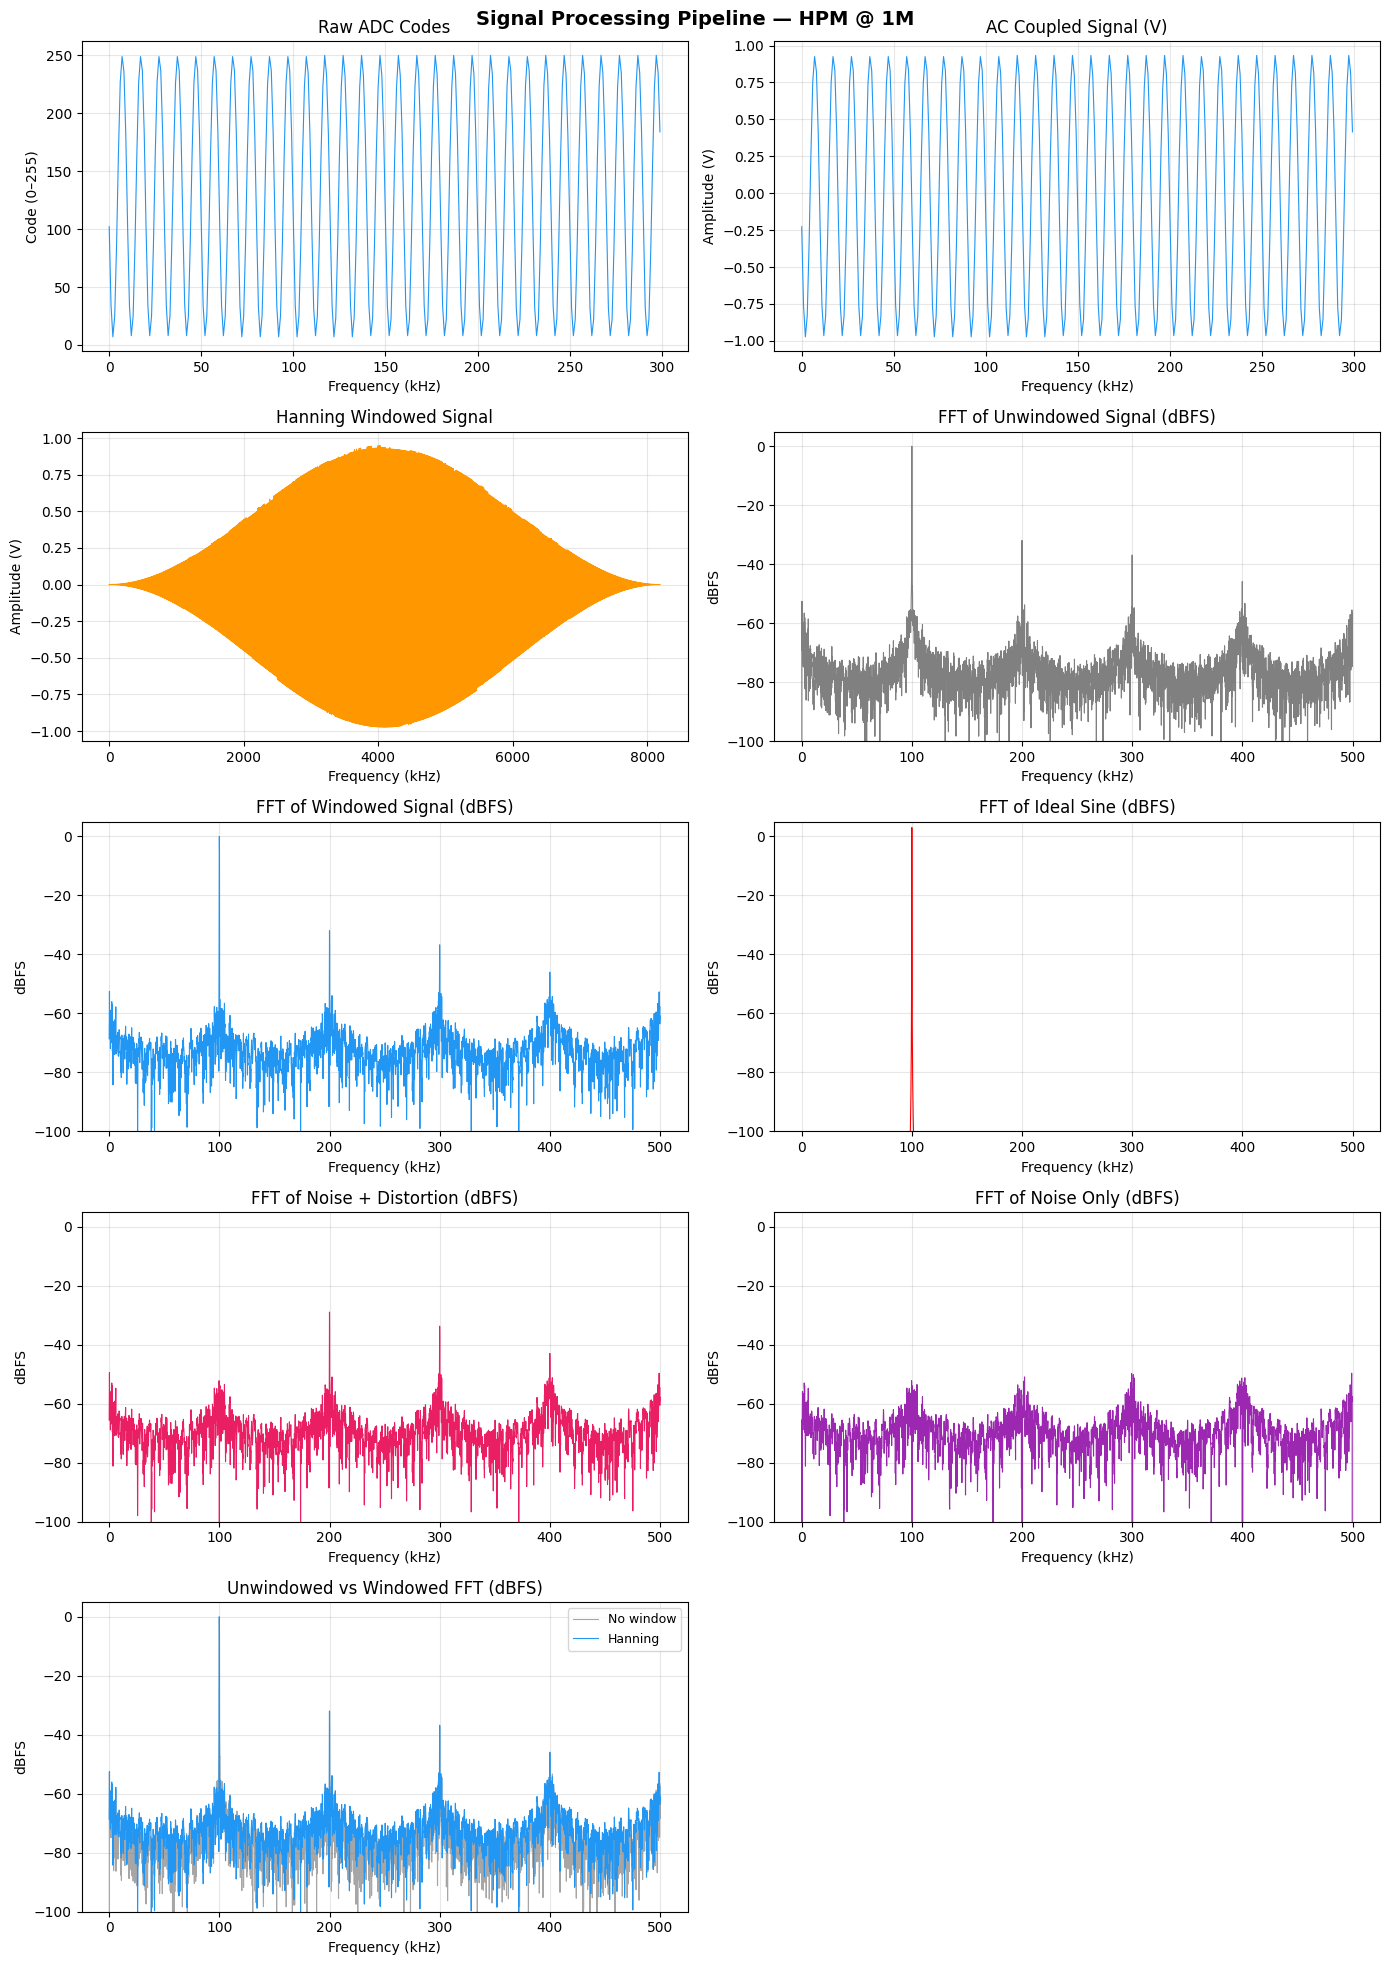

In [41]:
f_axis_khz = np.fft.fftfreq(BUFFER_SIZE, d=1.0/1e6)[:BUFFER_SIZE//2] / 1e3  # kHz
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
fig.suptitle(f"Signal Processing Pipeline — {HIGHLIGHT_PM} @ {HIGHLIGHT_FS}", fontsize=14, fontweight="bold")

axes[0, 0].plot(RAW_ADC_SIGNAL[:300], color="#2196F3", linewidth=0.8)
axes[0, 0].set_title("Raw ADC Codes"); axes[0, 0].set_ylabel("Code (0–255)")

axes[0, 1].plot(AC_COUPLED_SIGNAL[:300], color="#2196F3", linewidth=0.8)
axes[0, 1].set_title("AC Coupled Signal (V)"); axes[0, 1].set_ylabel("Amplitude (V)")

axes[1, 0].plot(HANNING_WINDOW_SIGNAL, color="#FF9800", linewidth=0.8)
axes[1, 0].set_title("Hanning Windowed Signal"); axes[1, 0].set_ylabel("Amplitude (V)")

axes[1, 1].plot(f_axis_khz, FFT_OF_UNWINDOWED_SIGNAL, color="gray", linewidth=0.8)
axes[1, 1].set_title("FFT of Unwindowed Signal (dBFS)"); axes[1, 1].set_ylabel("dBFS")
axes[1, 1].set_ylim(-100, 5)

axes[2, 0].plot(f_axis_khz, FFT_OF_HANNING_WINDOW_IN_DB, color="#2196F3", linewidth=0.8)
axes[2, 0].set_title("FFT of Windowed Signal (dBFS)"); axes[2, 0].set_ylabel("dBFS")
axes[2, 0].set_ylim(-100, 5)

axes[2, 1].plot(f_axis_khz, FFT_OF_IDEAL_SIGNAL, color="red", linewidth=0.8)
axes[2, 1].set_title("FFT of Ideal Sine (dBFS)"); axes[2, 1].set_ylabel("dBFS")
axes[2, 1].set_ylim(-100, 5)

axes[3, 0].plot(f_axis_khz, FFT_OF_NAD, color="#E91E63", linewidth=0.8)
axes[3, 0].set_title("FFT of Noise + Distortion (dBFS)"); axes[3, 0].set_ylabel("dBFS")
axes[3, 0].set_ylim(-100, 5)

axes[3, 1].plot(f_axis_khz, FFT_OF_NOISE_ONLY, color="#9C27B0", linewidth=0.8)
axes[3, 1].set_title("FFT of Noise Only (dBFS)"); axes[3, 1].set_ylabel("dBFS")
axes[3, 1].set_ylim(-100, 5)

axes[4, 0].plot(f_axis_khz, FFT_OF_UNWINDOWED_SIGNAL, color="gray",    linewidth=0.8, label="No window", alpha=0.7)
axes[4, 0].plot(f_axis_khz, FFT_OF_HANNING_WINDOW_IN_DB, color="#2196F3", linewidth=0.8, label="Hanning")
axes[4, 0].set_title("Unwindowed vs Windowed FFT (dBFS)"); axes[4, 0].set_ylabel("dBFS")
axes[4, 0].set_ylim(-100, 5); axes[4, 0].legend(fontsize=9)

axes[4, 1].axis("off")

for ax in axes.flat:
    if ax.get_title():
        ax.set_xlabel("Frequency (kHz)")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()